In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("ggplot")

In [74]:
scores = np.load("/content/feature_importances.npy")
idx = np.load("/content/feature_ranking_idx.npy")

Best validation result:
  top_k   = 680
  lambda  = 0.01
  val_acc = 0.87916

Test set results with best configuration:
Lambda: 0.01000, Train Acc: 0.90140, Test Acc: 0.50000, Precision: 0.49201, Recall: 0.50000, F1: 0.45632

In [75]:
selected_idx = idx[:680]
selected_idx = np.sort(selected_idx)

In [76]:
rows = []

for idx in selected_idx:
    rows.append({
        "global_index": idx,
        "sensor_id": idx // 60,
        "feature_method": idx % 60
    })

df_long = pd.DataFrame(rows)

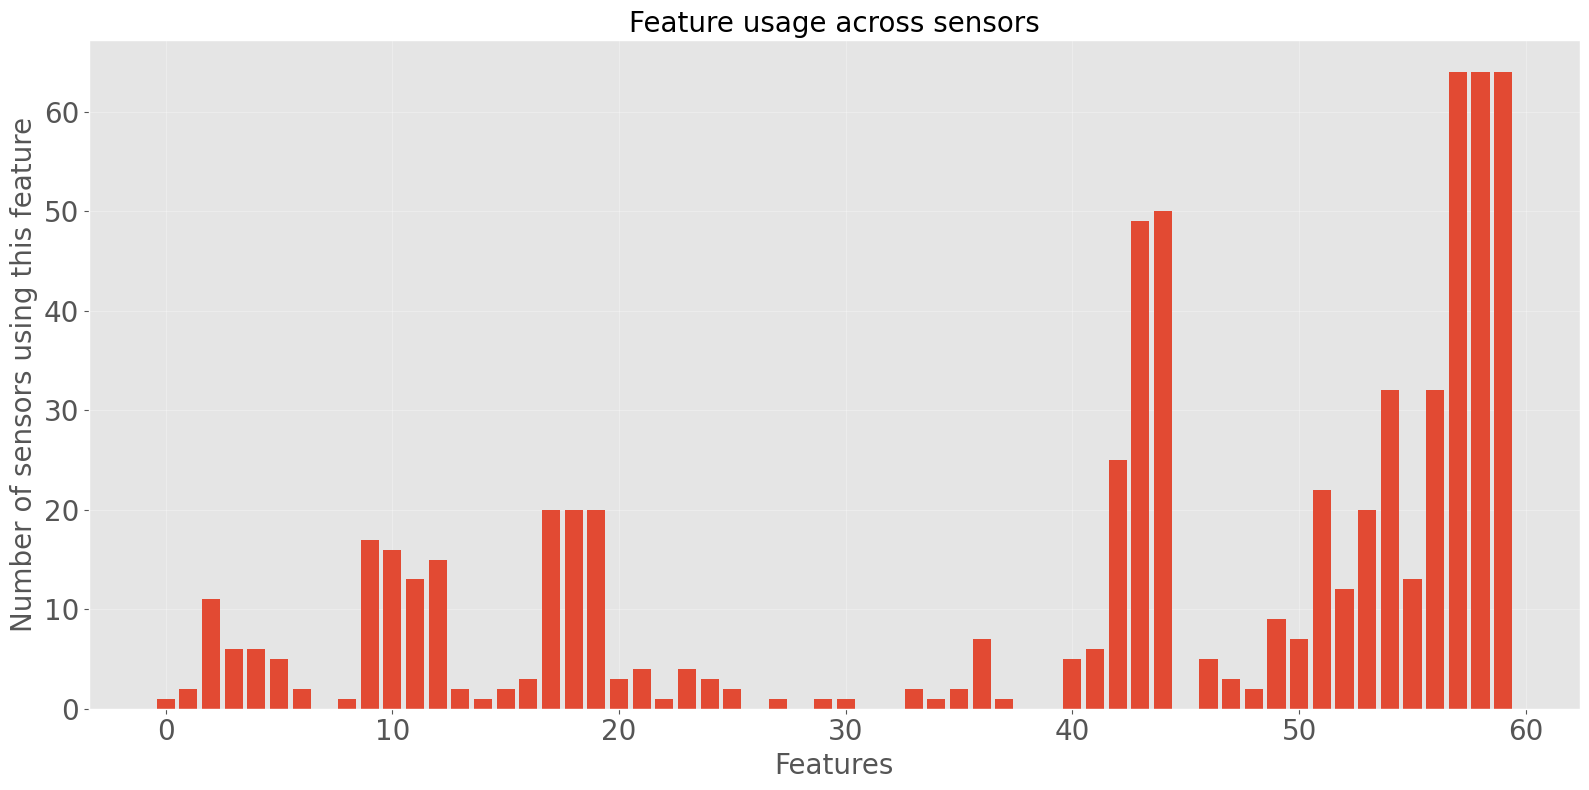

In [77]:
method_sensor_count = (
    df_long
    .groupby("feature_method")["sensor_id"]
    .nunique()
)

plt.figure(figsize=(16, 8))
plt.bar(method_sensor_count.index, method_sensor_count.values)
plt.xlabel("Features", fontsize=20)
plt.ylabel("Number of sensors using this feature", fontsize=20)
plt.title("Feature usage across sensors", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

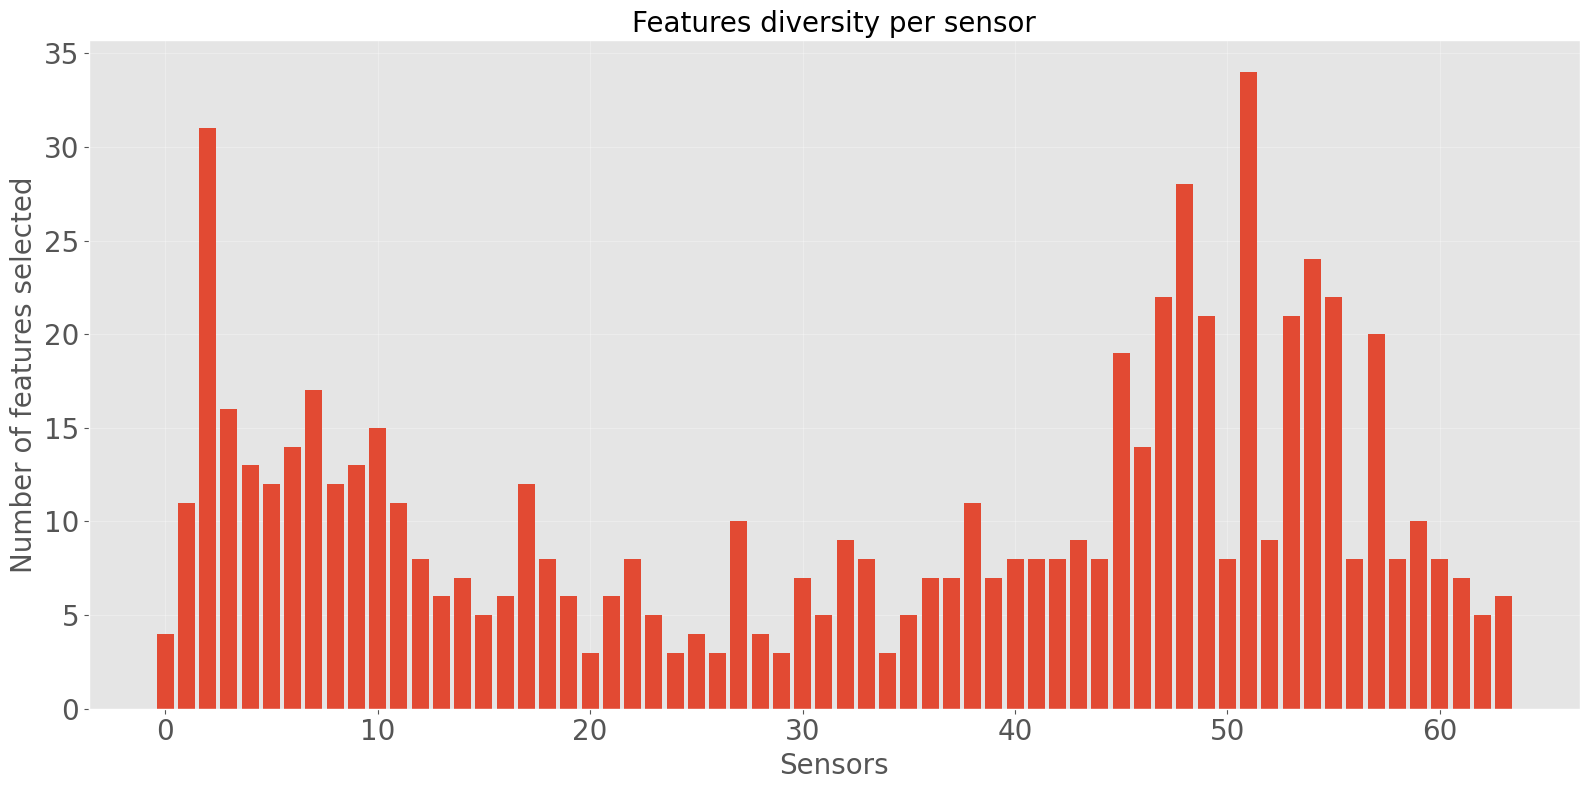

In [78]:
sensor_method_count = (
    df_long
    .groupby("sensor_id")["feature_method"]
    .nunique()
)

plt.figure(figsize=(16, 8))
plt.bar(sensor_method_count.index, sensor_method_count.values)
plt.xlabel("Sensors", fontsize=20)
plt.ylabel("Number of features selected", fontsize=20)
plt.title("Features diversity per sensor", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

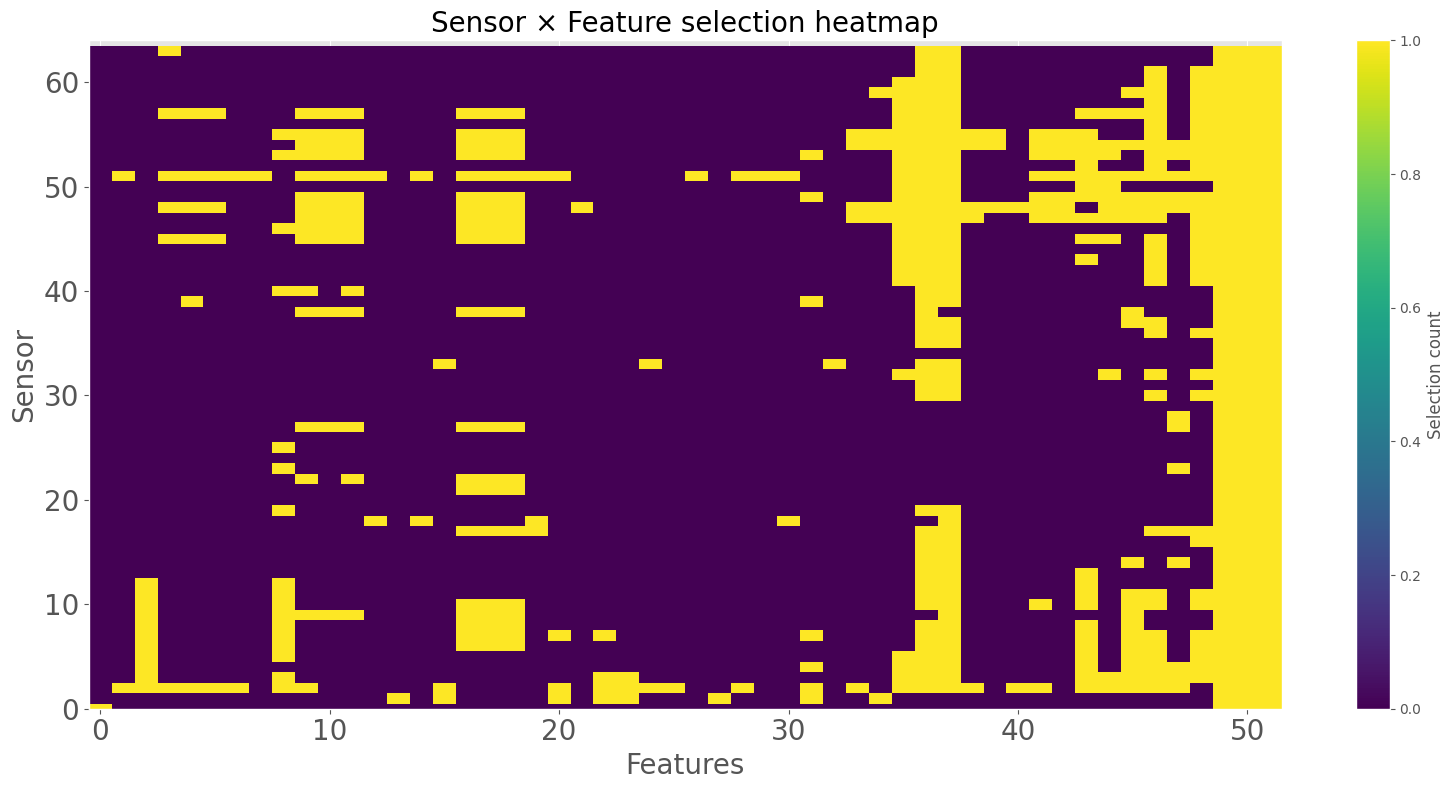

In [79]:
# Build selection matrix
selection_matrix = pd.crosstab(
    df_long["sensor_id"],
    df_long["feature_method"]
)

Z = selection_matrix.values

# Coordinates
x = np.arange(Z.shape[1])   # feature methods (0–60)
y = np.arange(Z.shape[0])   # sensors (0–101)

plt.figure(figsize=(16, 8))
pcm = plt.pcolormesh(
    x,
    y,
    Z,
    shading="nearest"
)

plt.colorbar(pcm, label="Selection count")
plt.xlabel("Features", fontsize=20)
plt.ylabel("Sensor", fontsize=20)
plt.title("Sensor × Feature selection heatmap", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# Ensure sensor 0 is at bottom, 100 at top
plt.ylim(0, Z.shape[0])

plt.tight_layout()
plt.show()

# pick the top 50 featues

In [80]:
method_counts = selection_matrix.sum(axis=0)

top_50_methods = (
    method_counts
    .sort_values(ascending=False)
    .head(50)
    .index
    .to_numpy()
)
top_50_methods

array([58, 59, 57, 44, 43, 54, 56, 42, 51, 17, 53, 18, 19,  9, 10, 12, 11,
       55, 52,  2, 49, 36, 50,  3,  4, 41, 40, 46,  5, 23, 21, 16, 47, 24,
       20,  1, 35, 48, 25, 13,  6, 15, 33,  0, 14,  8, 37, 34, 22, 27])

In [81]:
reduced_matrix = selection_matrix[top_50_methods]

sensor_method_counts = reduced_matrix.sum(axis=1)

sensor_method_counts.describe()

,0
count,64.000000
mean,10.593750
std,6.918388
min,3.000000
25%,6.000000
50%,8.000000
75%,13.000000
max,33.000000


In [82]:
from scipy.stats import entropy

method_entropy = selection_matrix.apply(
    lambda col: entropy(col + 1e-12), axis=0
)

top_50_entropy = method_entropy.sort_values(ascending=False).head(50)
top_50_entropy

,0
feature_method,
58,4.158883e+00
59,4.158883e+00
57,4.158883e+00
44,3.912023e+00
43,3.891820e+00
54,3.465736e+00
56,3.465736e+00
42,3.218876e+00
51,3.091042e+00


In [83]:
score = method_counts * method_entropy
top_50_methods = score.sort_values(ascending=False).head(50).index
top_50_methods

Index([58, 59, 57, 44, 43, 54, 56, 42, 51, 17, 53, 18, 19,  9, 10, 12, 11, 55,
       52,  2, 49, 36, 50,  3,  4, 41, 40, 46,  5, 23, 21, 24, 16, 20, 47,  1,
       33,  6, 35, 13, 15, 48, 25,  0, 30, 14, 27,  8, 37, 34],
      dtype='int64', name='feature_method')